# 01 - Data quality of the XBRL fact store

**Question:** can an analyst trust the numbers FinSight states? This notebook audits the DuckDB
fact store built from SEC `companyfacts` for the 12-company universe: how complete it is, how often
reported values are restated, why SEC's own `fy` label cannot be used, and whether the balance sheet
balances.

*Skills shown: SQL (window/aggregate), data validation, financial-statement semantics.*

In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

from finsight.config.settings import get_settings
from finsight.config.universe import load_universe
from finsight.ingestion.xbrl.store import FactStore
from finsight.ingestion.xbrl.quality import (
    check_accounting_identity, coverage_matrix, coverage_rate, identity_periods_checked, raw_availability,
    unexplained_gaps,
)

s = get_settings()
universe = load_universe(s.configs_dir / "universe.yaml")
store = FactStore(s.fact_db_path)
for table in ("facts", "fact_versions", "filings", "companies"):
    print(f"{table:14} {store.count(table):>8,} rows")

facts             9,146 rows
fact_versions    57,472 rows
filings              60 rows
companies            12 rows


## 1. Coverage: is every applicable value present?

Each cell is one *(company, metric, fiscal year)*. A gap is either **n/a** (a bank has no gross profit), **not reported** (declared with a reason in `configs/universe.yaml`) or **missing** (a bug).

raw availability      : 94.4%   (value present / every cell except sector-n/a)
unexplained gaps      : 0 cells
status
reported        1390
not reported      85
n/a               50
derived           35


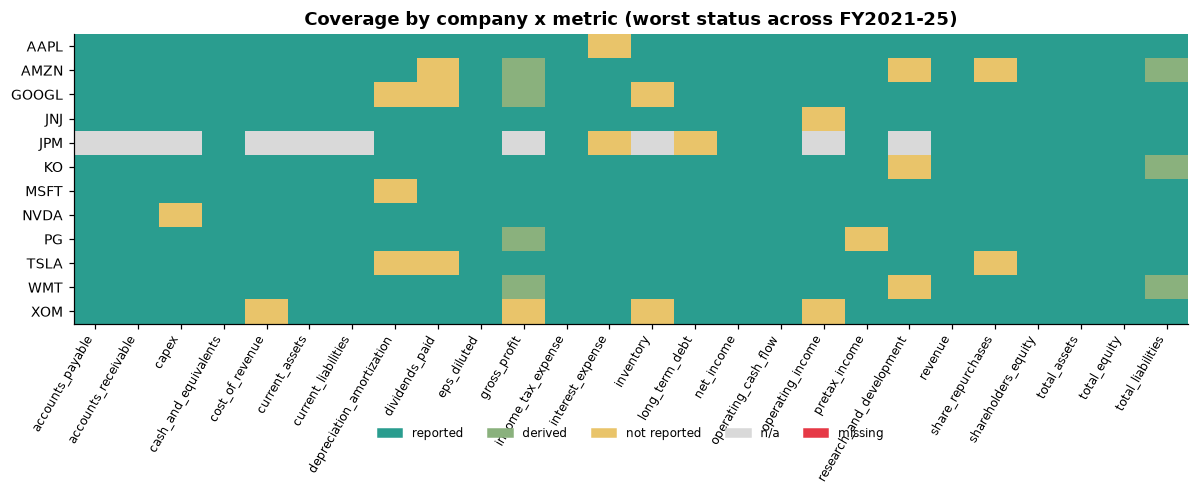

In [2]:
m = coverage_matrix(store, universe)
print(f"raw availability      : {raw_availability(m):.1%}   (value present / every cell except sector-n/a)")
print(f"unexplained gaps      : {len(unexplained_gaps(m))} cells")
print(m.status.value_counts().to_string())

order = {"reported": 0, "derived": 1, "not reported": 2, "n/a": 3, "missing": 4}
grid = m.assign(code=m.status.map(order)).groupby(["ticker", "metric"]).code.max().unstack("metric")
fig, ax = plt.subplots(figsize=(11, 4.6))
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#2a9d8f", "#8ab17d", "#e9c46a", "#d9d9d9", "#e63946"])
ax.imshow(grid.values, aspect="auto", cmap=cmap, vmin=0, vmax=4)
ax.set_xticks(range(len(grid.columns)), grid.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(grid.index)), grid.index, fontsize=9)
ax.grid(False)
ax.set_title("Coverage by company x metric (worst status across FY2021-25)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(cmap.colors, order)], ncol=5, loc="upper center",
          bbox_to_anchor=(0.5, -0.32), frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 2. Restatements: how often does a reported value change later?

The same annual figure is re-reported in later filings. Comparing values **within the same XBRL tag** shows how often a company revised (or recast) a number.

annual periods reported in more than one filing : 2,817
of which the value CHANGED between filings      : 300 (10.6%)


,ticker,metric,tag,end_date,lo,hi,rel_change
150,AMZN,eps_diluted,EarningsPerShareDiluted,2020-12-31,2.09,41.83,1901.4%
2183,GOOGL,eps_diluted,EarningsPerShareDiluted,2020-12-31,2.93,58.61,1900.3%
1798,AMZN,eps_diluted,EarningsPerShareDiluted,2021-12-31,3.24,64.81,1900.3%
536,GOOGL,eps_diluted,EarningsPerShareDiluted,2021-12-31,5.61,112.20,1900.0%
1213,TSLA,interest_expense,InterestExpenseDebt,2013-12-31,1200000.00,16288000.00,1257.3%
2989,NVDA,eps_diluted,EarningsPerShareDiluted,2023-01-29,0.17,1.74,923.5%
2990,NVDA,eps_diluted,EarningsPerShareDiluted,2024-01-28,1.19,11.93,902.5%
23,AAPL,eps_diluted,EarningsPerShareDiluted,2013-09-28,5.68,39.75,599.8%
1237,AAPL,eps_diluted,EarningsPerShareDiluted,2012-09-29,6.31,44.15,599.7%
25,AAPL,eps_diluted,EarningsPerShareDiluted,2019-09-28,2.97,11.89,300.3%


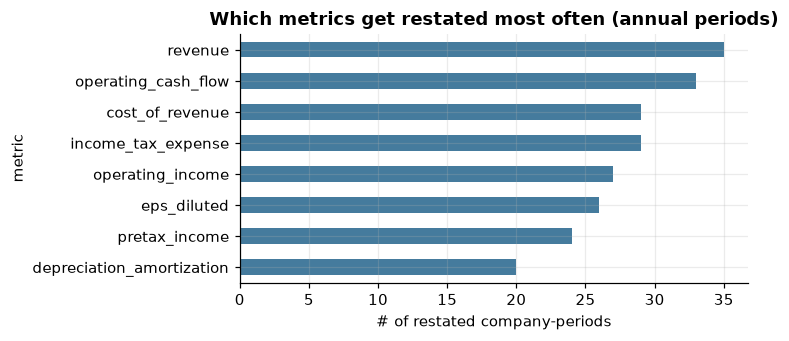

In [3]:
restated = store.sql('''
    WITH v AS (
        SELECT ticker, metric, tag, end_date, value FROM fact_versions
        WHERE start_date IS NOT NULL AND date_diff('day', start_date, end_date) BETWEEN 350 AND 380
    ), g AS (
        SELECT ticker, metric, tag, end_date, min(value) lo, max(value) hi, count(DISTINCT value) n_values, count(*) n_filings
        FROM v GROUP BY ALL
    )
    SELECT *, (hi - lo) / abs(NULLIF(lo, 0)) AS rel_change FROM g
''')
multi = restated[restated.n_filings > 1]
changed = multi[multi.n_values > 1]
print(f"annual periods reported in more than one filing : {len(multi):,}")
print(f"of which the value CHANGED between filings      : {len(changed):,} ({len(changed)/len(multi):.1%})")
display(changed.sort_values("rel_change", ascending=False).head(10)[["ticker", "metric", "tag", "end_date", "lo", "hi", "rel_change"]]
        .assign(rel_change=lambda d: (d.rel_change * 100).round(1).astype(str) + "%"))
by_metric = changed.groupby("metric").size().sort_values(ascending=False).head(8)
ax = by_metric[::-1].plot.barh(figsize=(7, 3.2), color="#457b9d")
ax.set_title("Which metrics get restated most often (annual periods)"); ax.set_xlabel("# of restated company-periods")
plt.tight_layout(); plt.show()

**Policy consequence:** `facts` keeps the *latest filed* value per period; `fact_versions` keeps every reported version, so 'as originally reported' remains answerable.

## 3. Why SEC's `fy` label cannot be trusted

Every 10-K reports several fiscal years side by side (comparatives). SEC tags all of them with the *filing's* fiscal year. FinSight derives the fiscal year from the period end date instead. Here is how many distinct annual periods each 10-K actually carries for revenue:

count    176.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0


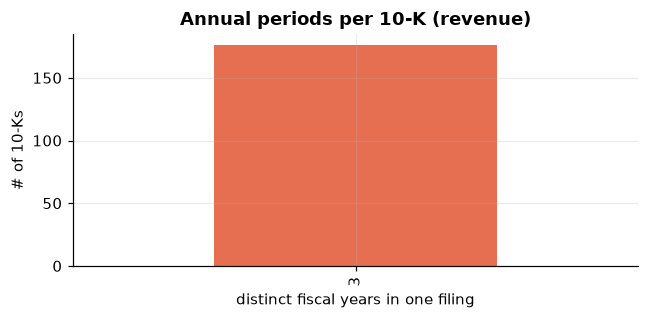

=> a 10-K carries 3.0 fiscal years on average, so labelling every value with the filing's year would be wrong for 67% of them.


In [4]:
per_filing = store.sql('''
    SELECT ticker, accession, form, count(DISTINCT end_date) AS annual_periods_in_filing
    FROM fact_versions
    WHERE metric = 'revenue' AND form = '10-K' AND start_date IS NOT NULL
      AND date_diff('day', start_date, end_date) BETWEEN 350 AND 380
    GROUP BY ALL
''')
print(per_filing.annual_periods_in_filing.describe().round(2).to_string())
ax = per_filing.annual_periods_in_filing.value_counts().sort_index().plot.bar(color="#e76f51", figsize=(6, 3))
ax.set_title("Annual periods per 10-K (revenue)"); ax.set_xlabel("distinct fiscal years in one filing"); ax.set_ylabel("# of 10-Ks")
plt.tight_layout(); plt.show()
mean_periods = per_filing.annual_periods_in_filing.mean()
print(f"=> a 10-K carries {mean_periods:.1f} fiscal years on average, so labelling every value with the filing's year "
      f"would be wrong for {1 - 1 / mean_periods:.0%} of them.")

## 4. Does the balance sheet balance?

`Assets = Liabilities + Total equity (+ redeemable NCI)`, using **reported** liabilities only (a derived value satisfies the identity by construction, which would prove nothing).

periods checked: 278    violations > 1%: 0
count    278.0000
mean       0.6389
std        4.3426
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max       45.5020


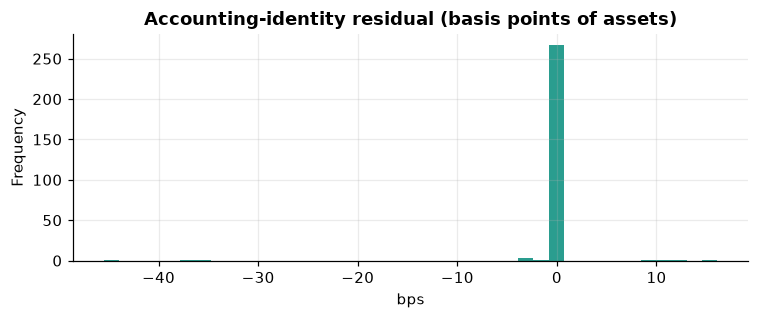

In [5]:
checked = identity_periods_checked(store)
bad = check_accounting_identity(store, tolerance=0.01)
print(f"periods checked: {checked}    violations > 1%: {len(bad)}")
resid = store.sql('''
    SELECT a.ticker, a.fiscal_year, a.fiscal_period,
           1e4 * (a.value - (l.value + e.value + COALESCE(m.value, 0))) / a.value AS residual_bps
    FROM facts a
    JOIN facts l ON l.ticker=a.ticker AND l.fiscal_year=a.fiscal_year AND l.fiscal_period=a.fiscal_period AND l.metric='total_liabilities' AND NOT l.derived
    JOIN facts e ON e.ticker=a.ticker AND e.fiscal_year=a.fiscal_year AND e.fiscal_period=a.fiscal_period AND e.metric='total_equity'
    LEFT JOIN facts m ON m.ticker=a.ticker AND m.fiscal_year=a.fiscal_year AND m.fiscal_period=a.fiscal_period AND m.metric='mezzanine_equity'
    WHERE a.metric='total_assets'
''')
print(resid.residual_bps.abs().describe().round(4).to_string())
ax = resid.residual_bps.plot.hist(bins=40, color="#2a9d8f", figsize=(7, 3))
ax.set_title("Accounting-identity residual (basis points of assets)"); ax.set_xlabel("bps")
plt.tight_layout(); plt.show()

## Findings

* The store is **complete where it can be**: every absent value is either not applicable to the
  sector or carries a written reason - none are unexplained.
* Restatements are **real and common enough to matter**, which is why the policy (latest wins, history kept) is explicit.
* Fiscal-year labels **must** be derived from dates; the SEC field describes the filing.
* The identity holds to well under a basis point once **total equity and redeemable NCI** are modelled.
  An earlier version that used parent-only equity flagged 48 'violations' - all of them
  non-controlling interests (Tesla, Exxon) - which is why parent and total equity are separate metrics.